In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

In [10]:
df = pd.read_csv('retail_sales_dataset.csv')
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

print(f'Filas: {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
print(f'Columnas existentes: {list(df.columns)}')

Filas: 120,000
Columnas: 17
Columnas existentes: ['transaction_id', 'transaction_date', 'customer_id', 'customer_gender', 'customer_age_group', 'customer_segment', 'product_id', 'product_name', 'category', 'brand', 'quantity', 'unit_price', 'discount_pct', 'sales_amount', 'payment_method', 'sales_channel', 'region']


In [11]:
# Primeras filas
print('\n--- Muestra del dataset ---')
print(df.head())

# Tipos de datos
print('\n--- Tipos de datos ---')
print(df.dtypes)

# Cuántos valores únicos tiene cada columna
print('\n--- Valores únicos por columna ---')
for col in df.columns:
    print(f'  {col}: {df[col].nunique():,}')

# Estadísticas básicas de columnas numéricas
print('\n--- Estadísticas descriptivas ---')
print(df.describe())


--- Muestra del dataset ---
  transaction_id transaction_date customer_id customer_gender  \
0       T0000001       2024-04-24     C000820           Other   
1       T0000002       2025-07-12     C002849           Other   
2       T0000003       2025-06-01     C019727            Male   
3       T0000004       2025-08-26     C009116            Male   
4       T0000005       2024-12-10     C003350            Male   

  customer_age_group customer_segment product_id   product_name  category  \
0              35-44        Returning      P1082      Dumbbells    Sports   
1              45-54              New      P1087  Running Shoes    Sports   
2                55+        Returning      P1030       Sneakers  Clothing   
3              25-34              VIP      P1058      Sunscreen    Beauty   
4              45-54              New      P1028       Sneakers  Clothing   

     brand  quantity  unit_price  discount_pct  sales_amount payment_method  \
0  Brand 1         2      313.53      

In [12]:
# --- Nulos ---
print('\n--- Valores nulos ---')
print(df.isnull().sum())

# --- Duplicados ---
print('\n--- Duplicados ---')
print(f'Filas duplicadas: {df.duplicated().sum()}')
print(f'IDs de transacción duplicados: {df["transaction_id"].duplicated().sum()}')

# --- transaction_date viene como texto en el CSV ---
print('\n--- Tipo de dato de transaction_date en el CSV original ---')
df_raw = pd.read_csv('retail_sales_dataset.csv')
print(f'  transaction_date es tipo: {df_raw["transaction_date"].dtype}')
print('  -> Hay que convertirla a datetime para poder hacer análisis de fechas')

# --- discount_pct solo tiene valores fijos ---
print('\n--- Valores únicos de discount_pct ---')
print(sorted(df['discount_pct'].unique()))
print('  -> Solo tiene 7 valores posibles (0, 5, 10, 15, 20, 25, 30)')
n_cero = (df['discount_pct'] == 0).sum()
print(f'  -> El {100*n_cero/len(df):.1f}% de las transacciones no tiene descuento')

# --- Mismo nombre de producto con distintos product_id ---
print('\n--- Productos con más de un product_id ---')
ids_por_nombre = df.groupby('product_name')['product_id'].nunique()
problemas = ids_por_nombre[ids_por_nombre > 1]
print(f'Nombres afectados: {len(problemas)} de {df["product_name"].nunique()}')
print(f'Total product_id únicos: {df["product_id"].nunique()} (hay solo {df["product_name"].nunique()} nombres)')
print(problemas)

# --- Atributos del cliente cambian entre compras ---
print('\n--- Clientes con atributos que cambian entre transacciones ---')
total = df['customer_id'].nunique()
seg = (df.groupby('customer_id')['customer_segment'].nunique() > 1).sum()
edad = (df.groupby('customer_id')['customer_age_group'].nunique() > 1).sum()
genero = (df.groupby('customer_id')['customer_gender'].nunique() > 1).sum()
print(f'  Segmento cambia:    {seg:,} clientes ({100*seg/total:.1f}%)')
print(f'  Edad cambia:        {edad:,} clientes ({100*edad/total:.1f}%)')
print(f'  Género cambia:      {genero:,} clientes ({100*genero/total:.1f}%)')
print('\n  Ejemplo — cliente C000001:')
print(df[df['customer_id'] == 'C000001']
      [['transaction_date', 'customer_segment', 'customer_age_group', 'customer_gender']]
      .sort_values('transaction_date').to_string(index=False))

# --- Outliers en sales_amount ---
print('\n--- Outliers en sales_amount ---')
Q1 = df['sales_amount'].quantile(0.25)
Q3 = df['sales_amount'].quantile(0.75)
IQR = Q3 - Q1
limite = Q3 + 1.5 * IQR
n_out = (df['sales_amount'] > limite).sum()
print(f'  Límite superior normal: ${limite:,.2f}')
print(f'  Valor máximo en datos:  ${df["sales_amount"].max():,.2f}')
print(f'  Registros con valores muy altos: {n_out:,} ({100*n_out/len(df):.1f}%)')


--- Valores nulos ---
transaction_id        0
transaction_date      0
customer_id           0
customer_gender       0
customer_age_group    0
customer_segment      0
product_id            0
product_name          0
category              0
brand                 0
quantity              0
unit_price            0
discount_pct          0
sales_amount          0
payment_method        0
sales_channel         0
region                0
dtype: int64

--- Duplicados ---
Filas duplicadas: 0
IDs de transacción duplicados: 0

--- Tipo de dato de transaction_date en el CSV original ---
  transaction_date es tipo: object
  -> Hay que convertirla a datetime para poder hacer análisis de fechas

--- Valores únicos de discount_pct ---
[np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30)]
  -> Solo tiene 7 valores posibles (0, 5, 10, 15, 20, 25, 30)
  -> El 60.0% de las transacciones no tiene descuento

--- Productos con más de un product_id ---
Nombres afectados:

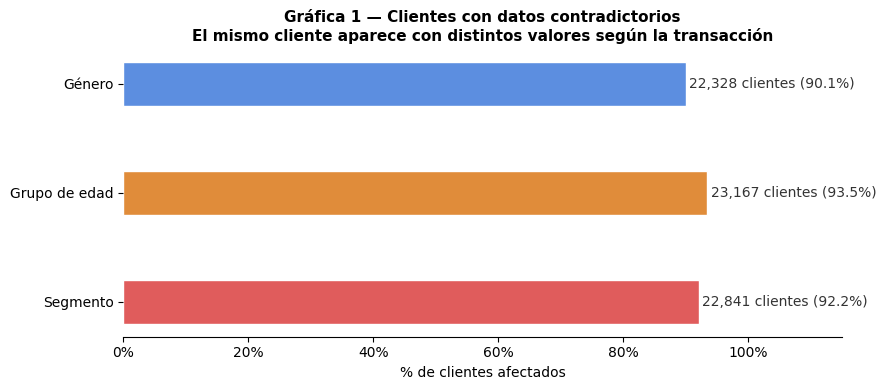

In [13]:
categorias = ['Segmento', 'Grupo de edad', 'Género']
valores = [seg, edad, genero]
porcentajes = [100 * v / total for v in valores]
colores = ['#E05C5C', '#E08C3A', '#5C8EE0']

fig, ax = plt.subplots(figsize=(9, 4))
barras = ax.barh(categorias, porcentajes, color=colores, height=0.4, edgecolor='white')

for barra, val, pct in zip(barras, valores, porcentajes):
    ax.text(pct + 0.5, barra.get_y() + barra.get_height() / 2,
            f'{val:,} clientes ({pct:.1f}%)',
            va='center', fontsize=10, color='#333')

ax.set_xlabel('% de clientes afectados', fontsize=10)
ax.set_xlim(0, 115)
ax.set_title(
    'Gráfica 1 — Clientes con datos contradictorios\n'
    'El mismo cliente aparece con distintos valores según la transacción',
    fontsize=11, fontweight='bold'
)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig('grafica_1_clientes_inconsistentes.png', dpi=150, bbox_inches='tight')
plt.show()

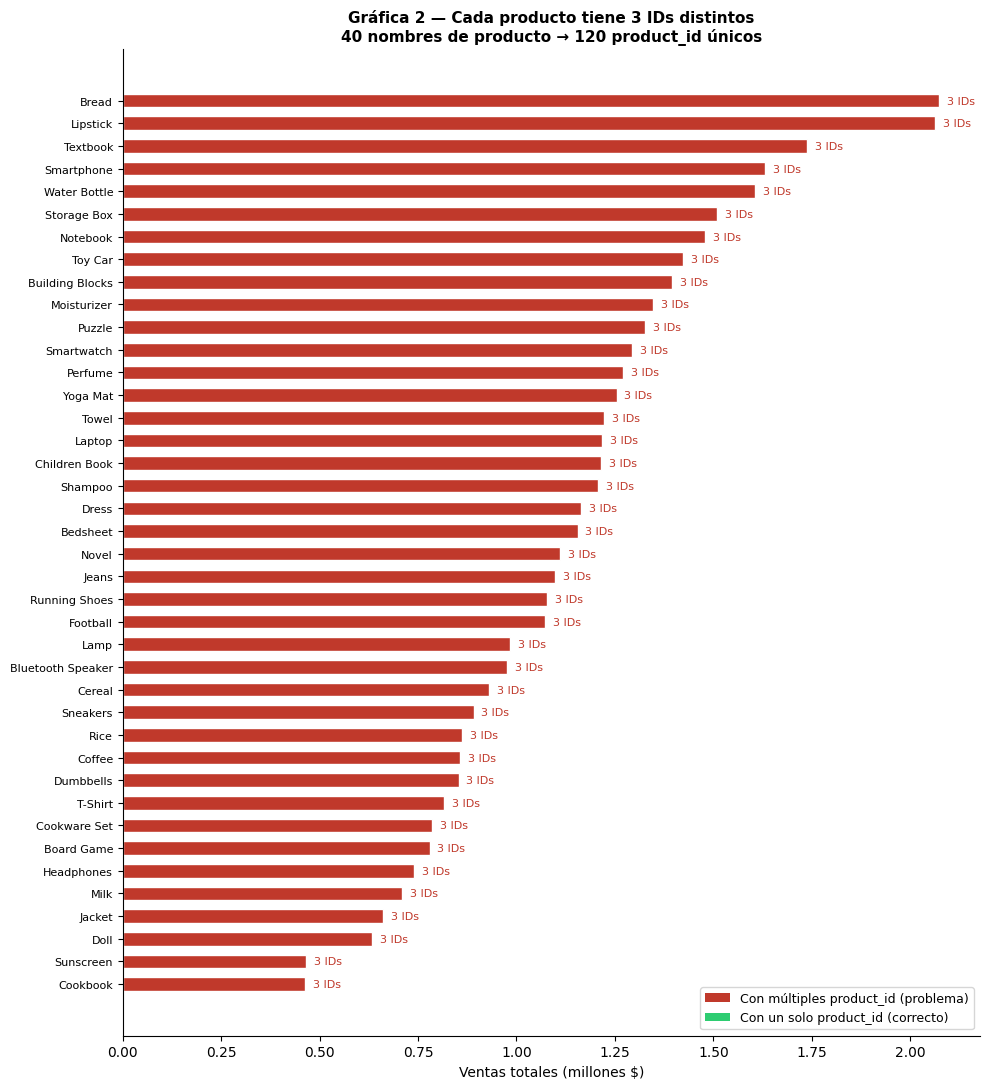

In [14]:
ventas_por_nombre = df.groupby('product_name')['sales_amount'].sum()
resumen = pd.DataFrame({
    'n_ids': ids_por_nombre,
    'ventas': ventas_por_nombre
}).sort_values('ventas', ascending=True)

colores_barras = ['#C0392B' if n > 1 else '#2ECC71' for n in resumen['n_ids']]

fig, ax = plt.subplots(figsize=(10, 11))
barras = ax.barh(resumen.index, resumen['ventas'] / 1e6,
                 color=colores_barras, height=0.6, edgecolor='white')

for barra, (nombre, fila) in zip(barras, resumen.iterrows()):
    ax.text(barra.get_width() + 0.02, barra.get_y() + barra.get_height() / 2,
            f'{int(fila["n_ids"])} IDs',
            va='center', fontsize=8,
            color='#C0392B' if fila['n_ids'] > 1 else '#27AE60')

leyenda = [
    Patch(facecolor='#C0392B', label='Con múltiples product_id (problema)'),
    Patch(facecolor='#2ECC71', label='Con un solo product_id (correcto)'),
]
ax.legend(handles=leyenda, fontsize=9)
ax.set_xlabel('Ventas totales (millones $)', fontsize=10)
ax.set_title(
    'Gráfica 2 — Cada producto tiene 3 IDs distintos\n'
    '40 nombres de producto → 120 product_id únicos',
    fontsize=11, fontweight='bold'
)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('grafica_2_productos_fragmentados.png', dpi=150, bbox_inches='tight')
plt.show()

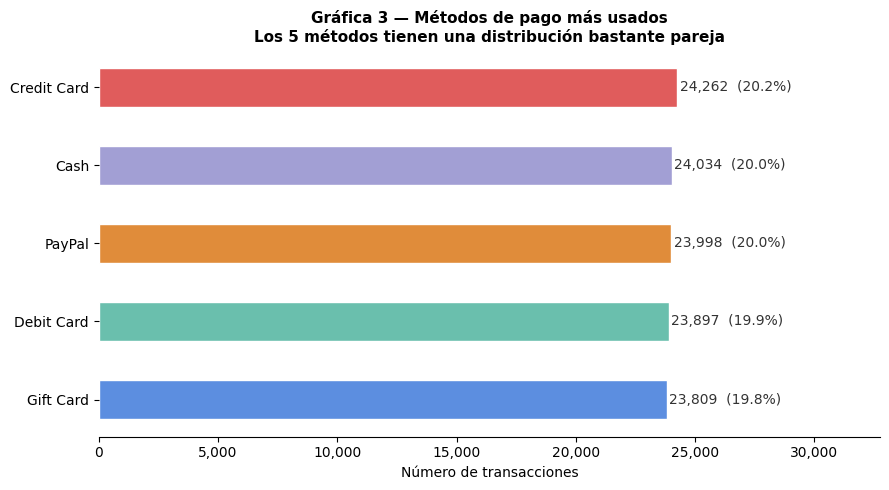

In [15]:
pagos = df['payment_method'].value_counts().sort_values(ascending=True)
colores_pago = ['#5C8EE0', '#6ABFAD', '#E08C3A', '#A29FD4', '#E05C5C']

fig, ax = plt.subplots(figsize=(9, 5))
barras3 = ax.barh(pagos.index, pagos.values, color=colores_pago, height=0.5, edgecolor='white')

for barra, val in zip(barras3, pagos.values):
    ax.text(barra.get_width() + 100, barra.get_y() + barra.get_height() / 2,
            f'{val:,}  ({100*val/len(df):.1f}%)',
            va='center', fontsize=10, color='#333')

ax.set_xlabel('Número de transacciones', fontsize=10)
ax.set_title(
    'Gráfica 3 — Métodos de pago más usados\n'
    'Los 5 métodos tienen una distribución bastante pareja',
    fontsize=11, fontweight='bold'
)
ax.set_xlim(0, pagos.max() * 1.35)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('grafica_3_metodos_pago.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
print('\n' + '=' * 60)
print('RESUMEN DE HALLAZGOS')
print('=' * 60)

print(f'\nDataset: {len(df):,} transacciones | {df.shape[1]} columnas')
print(f'Período: {df["transaction_date"].min().date()} al {df["transaction_date"].max().date()}')

print('\n Sin problemas:')
print('  - No hay valores nulos')
print('  - No hay filas duplicadas')

print('\n Problemas encontrados:')

print(f'\n  1. Datos del cliente cambian entre compras')
print(f'     El segmento, grupo de edad y género de un mismo cliente')
print(f'     no son consistentes a través de sus transacciones.')
print(f'     Clientes afectados: ~{seg:,} ({100*seg/total:.0f}% del total)')

print(f'\n  2. Cada producto tiene 3 IDs distintos')
print(f'     Hay 40 nombres de producto pero 120 product_id únicos.')
print(f'     Esto complica filtrar o agrupar por producto correctamente.')

print(f'\n  3. Los métodos de pago están distribuidos de forma muy pareja')
print(f'     Los 5 métodos (Credit Card, Cash, PayPal, Debit Card, Gift Card)')
print(f'     tienen casi el mismo número de transacciones (~20% cada uno).')
print(f'     Esto puede indicar que los datos fueron generados artificialmente.')

print(f'\n  4. Hay valores de venta muy altos (outliers)')
print(f'     {n_out:,} transacciones ({100*n_out/len(df):.1f}%) superan el rango normal.')
print(f'     El valor máximo es ${df["sales_amount"].max():,.2f}.')

print(f'\n  5. La fecha viene como texto en el CSV')
print(f'     transaction_date es string y necesita convertirse a datetime.')

print('\n' + '=' * 60)


RESUMEN DE HALLAZGOS

Dataset: 120,000 transacciones | 17 columnas
Período: 2024-01-01 al 2025-12-30

 Sin problemas:
  - No hay valores nulos
  - No hay filas duplicadas

 Problemas encontrados:

  1. Datos del cliente cambian entre compras
     El segmento, grupo de edad y género de un mismo cliente
     no son consistentes a través de sus transacciones.
     Clientes afectados: ~22,841 (92% del total)

  2. Cada producto tiene 3 IDs distintos
     Hay 40 nombres de producto pero 120 product_id únicos.
     Esto complica filtrar o agrupar por producto correctamente.

  3. Los métodos de pago están distribuidos de forma muy pareja
     Los 5 métodos (Credit Card, Cash, PayPal, Debit Card, Gift Card)
     tienen casi el mismo número de transacciones (~20% cada uno).
     Esto puede indicar que los datos fueron generados artificialmente.

  4. Hay valores de venta muy altos (outliers)
     8,309 transacciones (6.9%) superan el rango normal.
     El valor máximo es $2,467.55.

  5. La f